In [1]:
import numpy as np
import os
import PIL.Image
import tensorflow as tf
import pathlib
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')

In [2]:
!wget -q https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xzf flower_photos.tgz

In [3]:
data_dir = pathlib.Path('flower_photos')
print("Classes (folders):",[item.name for item in data_dir.glob('*') if item.is_dir()])
roses = list(data_dir.glob('roses/*'))
print(f'Total rose images found: {len(roses)}')

if roses:
    PIL.Image.open(str(roses[0])).show()
else:
    print("No rose image found.")

Classes (folders): ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Total rose images found: 641


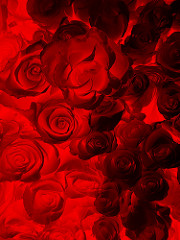

In [4]:
roses = list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[4]))

In [5]:
batch_size =32
img_height =224
img_width =224
train_data_gen= ImageDataGenerator(rescale=1./255, validation_split =0.2)
train_generator =train_data_gen.flow_from_directory(
    data_dir,
    target_size =(img_height, img_width),
    batch_size=batch_size,
    class_mode ='categorical',
    subset ='training'
)
val_generator=train_data_gen.flow_from_directory(
    data_dir,
    target_size =(img_height, img_width),
    batch_size=batch_size,
    class_mode ='categorical',
    subset ='validation'
)

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3), activation ='relu', input_shape =(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3), activation ='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128,(3,3), activation ='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(256,(3,3), activation ='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation ='relu'),
    tf.keras.layers.Dense(5, activation ='softmax')
])

In [ ]:
model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics =['accuracy'])
epochs=2
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data = val_generator
)
loss,accuracy = model.evaluate(val_generator)
print(f'Validation accuracy: {accuracy}')


Epoch 1/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.3251 - loss: 1.5936 - val_accuracy: 0.5239 - val_loss: 1.2185
Epoch 2/2
53/92 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.5811 - loss: 1.0374

In [ ]:
import math
import matplotlib.pyplot as plt

batch_size=5

batch_images, batch_labels =next(val_generator)

predictions = model.predict(batch_images)

num_images =min(batch_size, len(batch_images))

num_rows = math.ceil(num_images/5)
num_cols = min(num_images, 5)

class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(num_cols*3, num_rows*3))
for i in range(num_images):
    plt.subplot(num_rows, num_cols, i+1)
    plt.imshow(batch_images[i])
    plt.axis('off')
    predicted_class =np.argmax(predictions[i])
    true_class = np.argmax(batch_labels[i])
    plt.title(f'Predicted: {class_names[predicted_class]}, True: {class_names[true_class]}', fontsize =8)
plt.show()